In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [7]:
data=pd.read_excel('/content/roadaccident.xlsx',header=0)
print(data.columns)

Index(['NAME', 'VEHICLE.NO', 'VEHICLE. CC', 'VEHICLE BRAND', 'AGE', 'GENDER',
       'FAMILY INCOME', 'DRIVING LICENSE', 'RIDING AFTER AQURING LICENSE',
       'GAP B/W RIDING AND LICENSE', 'KM PER DAY', 'DRIVING EXP',
       'TYPE OF VEHICLE', 'AVG SPEED', 'DISTRACTION', 'CROSS RED LIGHT',
       'HELMET', 'NEVER:WHY?', 'OVERTAKE', 'MOBILE WHILE DRIVING',
       'LEG PROTRCTOR', 'ACCIDENTS  REASONS 1', 'REASON 2', 'REASON 3',
       'VEHICLE MAINTENANCE', 'SPEED LIMIT', 'INDICATORS', 'ALCOHOL OR DRUGS',
       'TRAFFIC RULES', 'RIDING WHILE TIRED', 'OVERTAKING IN JUNCTION',
       'BRAKE IN BEND', 'SPEED', 'DRUNKEN DRIVE', 'CONCENTRATION',
       'MOBILE WHILE DRIVING.1', 'FATIGUE', 'INEXPERIENCE',
       'CLOSE TO OTHER VEHICLE', 'CARELESSNESS', 'IGNORE TRAFFIC RULES',
       'POOR ROAD CONDITIONS', 'POOR ROAD DESIGEN', 'WEATHER',
       'OTHERS CARELESSNESS', 'SHOWING OFF', 'NO VEHICLE MAINTENANCE',
       'GOOD TRAFFIC RULES IN INDIA', 'MET WITH AN ACCIDENT?',
       'NO.OF ACCIDEN

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 91 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   NAME                          251 non-null    object 
 1   VEHICLE.NO                    236 non-null    float64
 2   VEHICLE. CC                   251 non-null    int64  
 3   VEHICLE BRAND                 251 non-null    int64  
 4   AGE                           251 non-null    object 
 5   GENDER                        251 non-null    int64  
 6   FAMILY INCOME                 251 non-null    int64  
 7   DRIVING LICENSE               251 non-null    int64  
 8   RIDING AFTER AQURING LICENSE  251 non-null    int64  
 9   GAP B/W RIDING AND LICENSE    251 non-null    int64  
 10  KM PER DAY                    251 non-null    int64  
 11  DRIVING EXP                   251 non-null    int64  
 12  TYPE OF VEHICLE               251 non-null    int64  
 13  AVG S

In [9]:
data.isna().sum()

,0
NAME,0
VEHICLE.NO,15
VEHICLE. CC,0
VEHICLE BRAND,0
AGE,0
...,...
ACCIDENT WITH5,0
REASON 5,0
ROAD CONDITION 5,0
ROAD CON 5,0


In [10]:
X=data.drop(["MET WITH AN ACCIDENT?"],axis=1)
print(X)
y=data["MET WITH AN ACCIDENT?"]
print(y)

              NAME  VEHICLE.NO  VEHICLE. CC  VEHICLE BRAND    AGE  GENDER  \
0        SRAVANTHI      3201.0           90              5  19-21       2   
1          SRIVANI      1546.0          110              4  19-21       2   
2    ROOPA MADHURI      4122.0          110              4  41-45       2   
3       Y SRINIVAS      8885.0          110              4  46-50       1   
4           SATISH      5193.0         1500              4    >60       1   
..             ...         ...          ...            ...    ...     ...   
246     G BHARGAVI      8946.0          120              6  18-25       2   
247       RAJA RAM      5466.0          130              5    >27       1   
248         JADAV       9147.0          125              4  19-21       1   
249         ARVIND      7452.0          150              2  13-15       1   
250      MAHENDRA       8266.0          110              2    >27       1   

     FAMILY INCOME  DRIVING LICENSE  RIDING AFTER AQURING LICENSE  \
0     

In [11]:
X=pd.get_dummies(X,dtype='int',drop_first=True)
print(X)

     VEHICLE.NO  VEHICLE. CC  VEHICLE BRAND  GENDER  FAMILY INCOME  \
0        3201.0           90              5       2              4   
1        1546.0          110              4       2              1   
2        4122.0          110              4       2              4   
3        8885.0          110              4       1              4   
4        5193.0         1500              4       1              4   
..          ...          ...            ...     ...            ...   
246      8946.0          120              6       2              4   
247      5466.0          130              5       1              4   
248      9147.0          125              4       1              4   
249      7452.0          150              2       1              4   
250      8266.0          110              2       1              3   

     DRIVING LICENSE  RIDING AFTER AQURING LICENSE  \
0                  2                             2   
1                  2                             2 

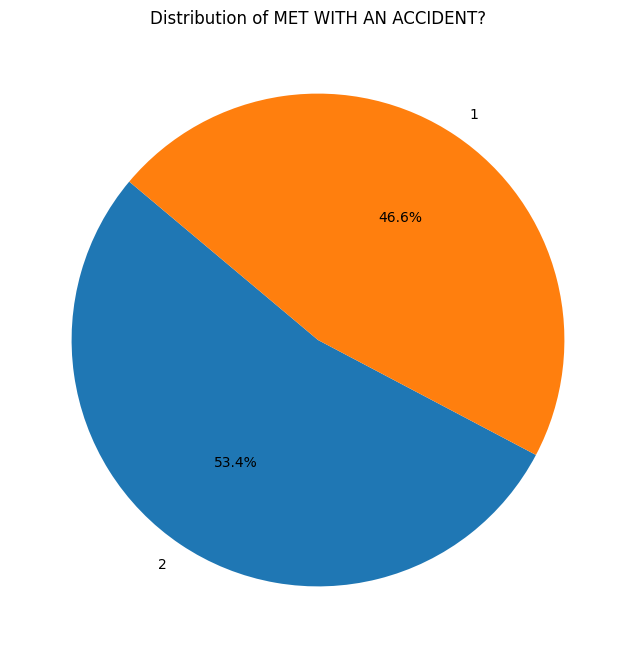

In [12]:
column_name = 'MET WITH AN ACCIDENT?'  # Change this to the column you want to visualize
column_data = data[column_name].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(column_data, labels=column_data.index, autopct='%1.1f%%', startangle=140)
plt.title(f"Distribution of {column_name}")
plt.show()

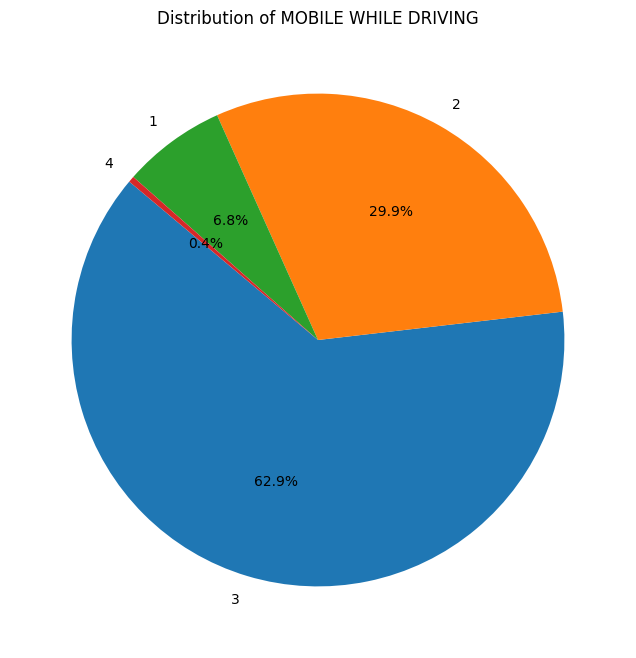

In [14]:
column_name = 'MOBILE WHILE DRIVING'  # Change this to the column you want to visualize
column_data = data[column_name].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(column_data, labels=column_data.index, autopct='%1.1f%%', startangle=140)
plt.title(f"Distribution of {column_name}")
plt.show()

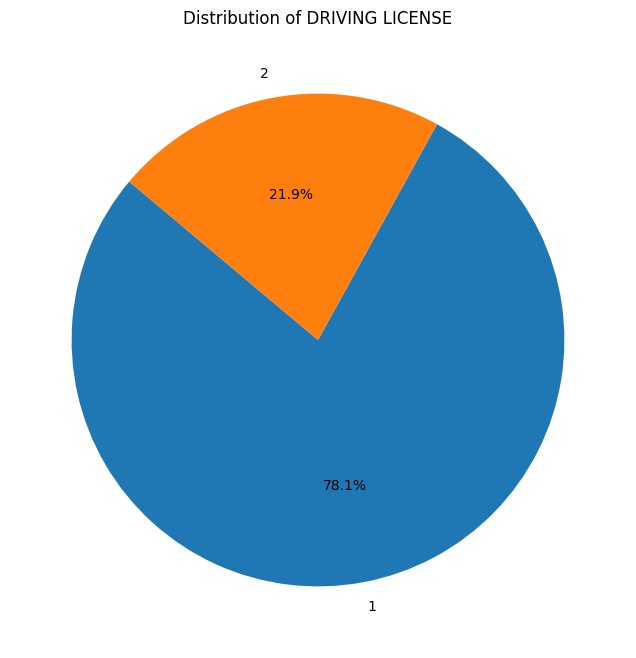

In [13]:
column_name = 'DRIVING LICENSE'  # Change this to the column you want to visualize
column_data = data[column_name].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(column_data, labels=column_data.index, autopct='%1.1f%%', startangle=140)
plt.title(f"Distribution of {column_name}")
plt.show()

logistic regression

In [43]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.1, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# AdaBoost Classifier with Decision Trees as the base estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_preds = adaboost.predict(X_test)

# Gradient Boosting Classifier
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
boosting_preds = boosting.predict(X_test)


# Decision Tree
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)
dec_tree_preds = dec_tree.predict(X_test)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Bagging Classifier Accuracy:", accuracy_score(y_test, bagging_preds))
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, adaboost_preds))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, boosting_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dec_tree_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.6153846153846154
Bagging Classifier Accuracy: 0.8846153846153846
AdaBoost Classifier Accuracy: 0.8076923076923077
Gradient Boosting Classifier Accuracy: 0.7692307692307693
Decision Tree Accuracy: 0.8461538461538461
Naive Bayes Accuracy: 0.6538461538461539
Random Forest Accuracy: 0.8846153846153846


In [42]:


# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.2, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# AdaBoost Classifier with Decision Trees as the base estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_preds = adaboost.predict(X_test)

# Gradient Boosting Classifier
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
boosting_preds = boosting.predict(X_test)


# Decision Tree
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)
dec_tree_preds = dec_tree.predict(X_test)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Bagging Classifier Accuracy:", accuracy_score(y_test, bagging_preds))
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, adaboost_preds))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, boosting_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dec_tree_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.6470588235294118
Bagging Classifier Accuracy: 0.803921568627451
AdaBoost Classifier Accuracy: 0.7450980392156863
Gradient Boosting Classifier Accuracy: 0.7058823529411765
Decision Tree Accuracy: 0.7647058823529411
Naive Bayes Accuracy: 0.6274509803921569
Random Forest Accuracy: 0.7450980392156863


In [41]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.25, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# AdaBoost Classifier with Decision Trees as the base estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_preds = adaboost.predict(X_test)

# Gradient Boosting Classifier
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
boosting_preds = boosting.predict(X_test)


# Decision Tree
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)
dec_tree_preds = dec_tree.predict(X_test)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Bagging Classifier Accuracy:", accuracy_score(y_test, bagging_preds))
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, adaboost_preds))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, boosting_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dec_tree_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.6190476190476191
Bagging Classifier Accuracy: 0.6825396825396826
AdaBoost Classifier Accuracy: 0.7142857142857143
Gradient Boosting Classifier Accuracy: 0.746031746031746
Decision Tree Accuracy: 0.6825396825396826
Naive Bayes Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.7142857142857143


In [40]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.3, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# AdaBoost Classifier with Decision Trees as the base estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_preds = adaboost.predict(X_test)

# Gradient Boosting Classifier
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
boosting_preds = boosting.predict(X_test)


# Decision Tree
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)
dec_tree_preds = dec_tree.predict(X_test)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Bagging Classifier Accuracy:", accuracy_score(y_test, bagging_preds))
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, adaboost_preds))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, boosting_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dec_tree_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.5789473684210527
Bagging Classifier Accuracy: 0.6973684210526315
AdaBoost Classifier Accuracy: 0.618421052631579
Gradient Boosting Classifier Accuracy: 0.6578947368421053
Decision Tree Accuracy: 0.6447368421052632
Naive Bayes Accuracy: 0.6447368421052632
Random Forest Accuracy: 0.6578947368421053


In [39]:


X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.4, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# AdaBoost Classifier with Decision Trees as the base estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
adaboost_preds = adaboost.predict(X_test)

# Gradient Boosting Classifier
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
boosting_preds = boosting.predict(X_test)


# Decision Tree
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)
dec_tree_preds = dec_tree.predict(X_test)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Bagging Classifier Accuracy:", accuracy_score(y_test, bagging_preds))
print("AdaBoost Classifier Accuracy:", accuracy_score(y_test, adaboost_preds))
print("Gradient Boosting Classifier Accuracy:", accuracy_score(y_test, boosting_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dec_tree_preds))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.594059405940594
Bagging Classifier Accuracy: 0.7029702970297029
AdaBoost Classifier Accuracy: 0.6831683168316832
Gradient Boosting Classifier Accuracy: 0.693069306930693
Decision Tree Accuracy: 0.6534653465346535
Naive Bayes Accuracy: 0.6039603960396039
Random Forest Accuracy: 0.6831683168316832


Bagging Classifier Confusion Matrix:
[[11  2]
 [ 1 12]]


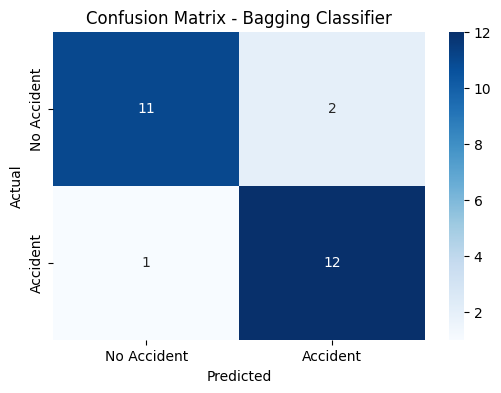

In [37]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_features, data['MET WITH AN ACCIDENT?'], test_size=0.1, random_state=42)

# Convert sparse matrix to dense
X_train = X_train.toarray()
X_test = X_test.toarray()

# Bagging Classifier with Decision Trees
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, bagging_preds)
print("Bagging Classifier Confusion Matrix:")
print(cm)

# Plotting Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Accident', 'Accident'], yticklabels=['No Accident', 'Accident'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bagging Classifier')
plt.show()

